# **Entrega Final**
# Data Science I
### Fecha: 17/07/2024

## Objetivos:

### Estudio de Modelos Análiticos
  
- Crearás un notebook que complemente el trabajo realizado en los siguientes apartados:
    - I) Elegir un método de feature selection para reducir la dimensionalidad del dataset.
    - II) Elegir un algoritmo de regresión o clasificación para entrenar con los datos elegidos.
    - III) Cálculo de métricas básicas para validar el modelo.
    - IV) Generar conclusiones con base en los resultados obtenidos.

#Abstracto

El objetivo de este proyecto es analizar y visualizar datos del mercado inmobiliario del condado de King. Mediante el uso de bibliotecas de Python como Pandas, Matplotlib y Seaborn, se han desarrollado diversas visualizaciones que nos permiten entender mejor las variables que influyen en los precios de las casas (variable a predecir). A través de este análisis, se busca responder a preguntas clave y validar hipótesis sobre las características de las propiedades y su impacto en el precio de venta. El análisis inicial sugiere que variables como el tamaño de la casa en metros cuadrados y la condición general de la propiedad tienen una relación significativa con el precio de venta. Además, se han identificado patrones interesantes en función del precio en relacion con las casas con vista al agua como tambien la inferencia del numero de habitaciones. Se han creado visualizaciones han permitido realizar un diagnóstico detallado de los datos y obtener insights valiosos. Estas visualizaciones no solo ayudan a validar nuestras hipótesis iniciales, sino que también plantean nuevas preguntas sobre el mercado inmobiliario del condado de King. Por ejemplo, se ha planteado la hipótesis de que las casas con mayor calificación y mejor condición tienen precios superiores, lo cual ha sido parcialmente confirmado. En resumen, este análisis proporciona una base sólida para comprender las dinámicas del mercado inmobiliario en el condado de King y abre la puerta a estudios más profundos y específicos en el futuro.

Dataset fue tomado de :[ https://www.kaggle.com/datasets/harlfoxem/housesalesprediction ]

### Diccionario de datos "Variables"

id : numero de identificacion de la casa

date: fecha de venta

price: precio

bedrooms: cuartos

bathrooms: baños

sqft_living: metros cuadrados casa

sqft_lot: metros cuadrados lote

floors : pisos o niveles o plantas

waterfront : vista al agua

view: si ya tuvo vistas

condition : condicion de la casa del 1 al 5

grade: Calificación general otorgada a la unidad de vivienda, según el sistema de calificación del condado de King

sqft_above : Metros cuadrados de la casa sin contar el sotano

sqft_basement: Metros cuadrados del sotano

yr_built : año de construccion

yr_renovated : año de renovacion

zipcode: codigo postal

lat: latitud coordenada

long: longitud coordenada

sqft_living15 : Área de la sala de estar en 2015 (implica algunas renovaciones) Esto podría haber afectado o no el área del lote.

sqft_lot15 : Superficie del lote en 2015 (implica algunas renovaciones)

## Importación Dataset

In [65]:
import pandas as pd

In [66]:
#Import dataset
df = pd.read_csv("/content/drive/MyDrive/Data Science Proyecto Coder House/kc_house_data.csv")

In [67]:
df.head(2)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639


In [68]:
df.shape

(21613, 21)

In [69]:
df.tail(2)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [70]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [71]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [72]:
df.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4.580302e+09,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2.876566e+09,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1.000102e+06,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2.123049e+09,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7.308900e+09,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9.900000e+09,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00


#Modelo Analítico

En este proyecto, se utilizará el aprendizaje supervisado para predecir el precio de venta de las casas en el condado de King. La variable objetivo será el precio de las casas (price), y las características (features) utilizadas serán variables como sqft_living, bedrooms, bathrooms, grade, condition, y waterfront. Se utilizará un algoritmo de regresión, específicamente la regresión lineal, ya que la variable objetivo es continua.


###Contexto Comercial

En el contexto del mercado inmobiliario, entender los factores que influyen en el precio de las casas es crucial para compradores, vendedores, y agentes inmobiliarios. Los resultados de este análisis pueden ser utilizados por agentes inmobiliarios y desarrolladores para realizar tasaciones más precisas y tomar decisiones informadas sobre la compra y venta de propiedades.

###Problema Comercial

El problema está asociado a cómo la información proporcionada por el modelo de regresión puede ayudar a desarrollar estrategias más efectivas en la valoración de propiedades. Es necesario determinar el conjunto de factores que influyen en el precio de venta de las casas para mejorar la precisión de las tasaciones y optimizar las estrategias de mercado. Dado que el precio de venta es una variable crítica, se estudiarán las características de las propiedades que tienen un mayor impacto en este precio.

###Hipótesis específicas:
1. Las casas con vista al agua tienen un precio significativamente mayor que aquellas sin vista.
2. El número de habitaciones no es un indicador tan fuerte del precio como lo son los metros cuadrados de la casa.
3. Las casas con mejor calificación y condición tienen precios de venta superiores.

# Exploratory Data Analysis

### Importación de Librerias

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [74]:
# Eliminación de duplicados
df = df.drop_duplicates()

In [75]:
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [76]:
df['date'] = pd.to_datetime(df['date'])

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   2161

No se presentan valores nulos

###Visualizaciones

Precio vs. Metros Cuadrados de Vivienda

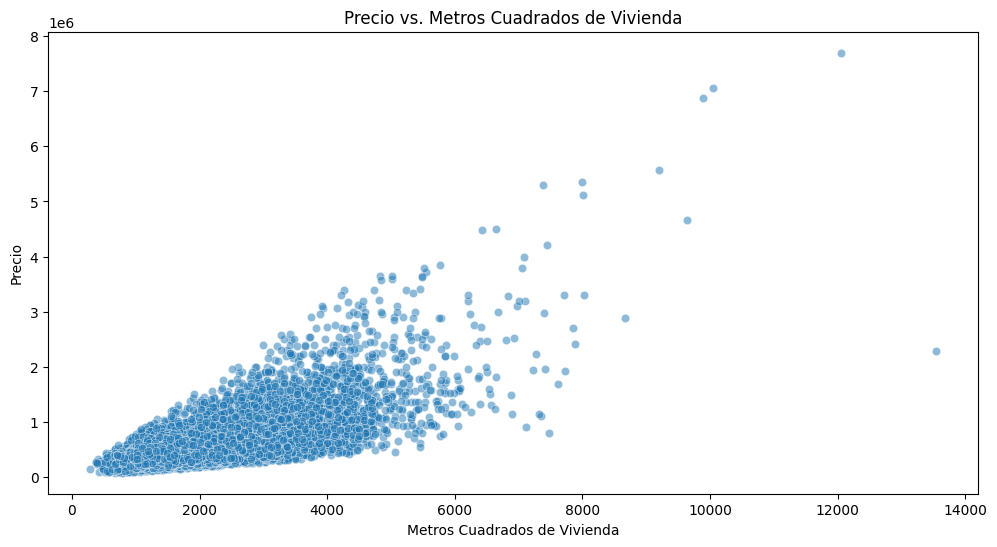

In [78]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.5)
plt.title('Precio vs. Metros Cuadrados de Vivienda')
plt.xlabel('Metros Cuadrados de Vivienda')
plt.ylabel('Precio')
plt.show()

Análisis de Variables Categóricas

Número de Habitaciones

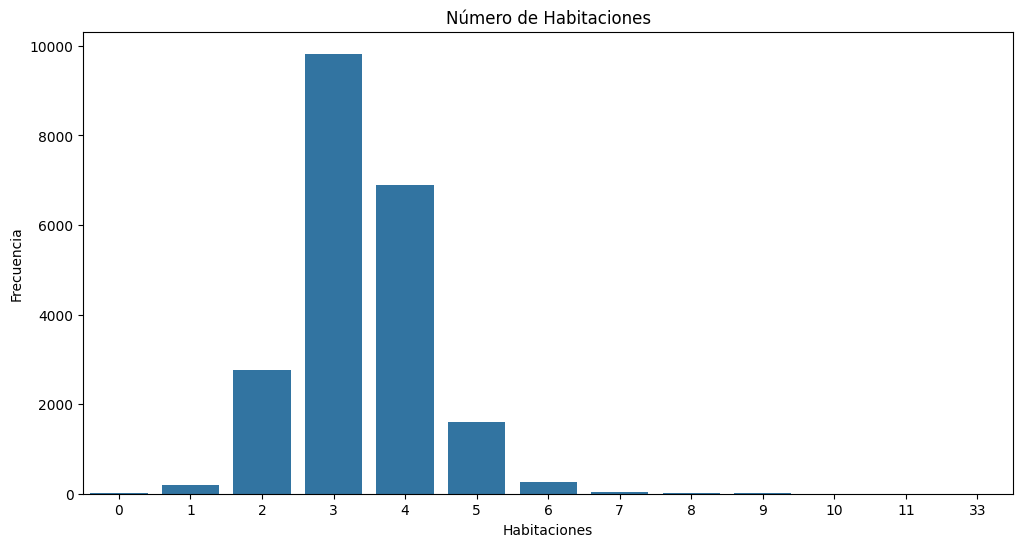

In [79]:
plt.figure(figsize=(12, 6))
sns.countplot(x='bedrooms', data=df)
plt.title('Número de Habitaciones')
plt.xlabel('Habitaciones')
plt.ylabel('Frecuencia')
plt.show()

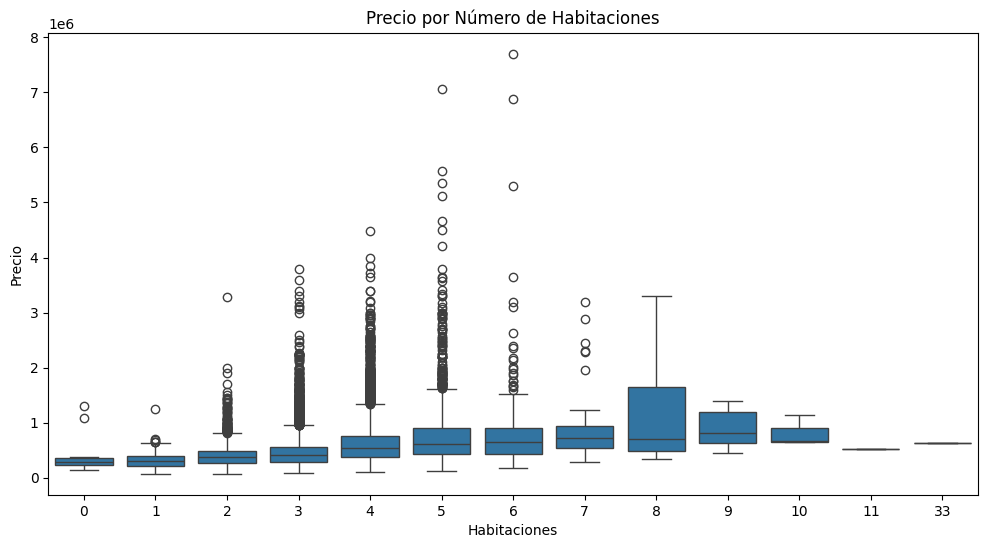

In [80]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Precio por Número de Habitaciones')
plt.xlabel('Habitaciones')
plt.ylabel('Precio')
plt.show()

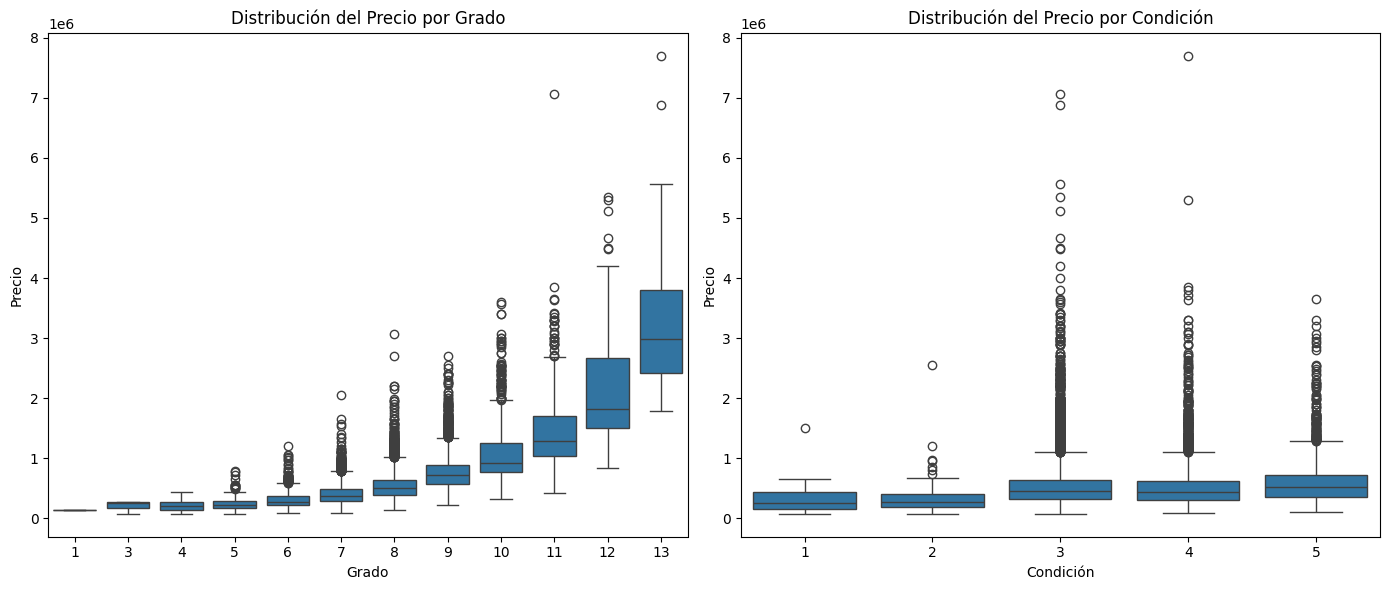

In [81]:
plt.figure(figsize=(14, 6))

# Distribución del Precio por Grado
plt.subplot(1, 2, 1)
sns.boxplot(x='grade', y='price', data=df)
plt.title('Distribución del Precio por Grado')
plt.xlabel('Grado')
plt.ylabel('Precio')

# Distribución del Precio por Condición
plt.subplot(1, 2, 2)
sns.boxplot(x='condition', y='price', data=df)
plt.title('Distribución del Precio por Condición')
plt.xlabel('Condición')
plt.ylabel('Precio')

plt.tight_layout()
plt.show()

###Machine learning

Linear Regression

Feature selection

In [82]:
from sklearn.linear_model import Lasso

# Entrena un modelo Lasso
model = Lasso(alpha=0.1)
model.fit(X, y)

# Obtén las características seleccionadas
lasso_features = X.columns[model.coef_ != 0]
print("Características seleccionadas por Lasso: %s" % lasso_features)

Características seleccionadas por Lasso: Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.981e+14, tolerance: 2.913e+11
  model = cd_fast.enet_coordinate_descent(


Preparacion de los datos

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Cargar los datos
df = pd.read_csv('/content/drive/MyDrive/Data Science Proyecto Coder House/kc_house_data.csv')

# Seleccionar las características y la variable objetivo
X = df.drop(['price', 'date'], axis=1)  # Excluir la columna 'date'
y = df['price']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar los datos (opcional dependiendo del modelo)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.select_dtypes(include=['number']))  # Escalar solo las columnas numéricas
X_test = scaler.transform(X_test.select_dtypes(include=['number']))

# Verificar las dimensiones de los datos transformados
print(X_train.shape, X_test.shape)

(17290, 19) (4323, 19)


Entrenamiento del Modelo

In [84]:
from sklearn.tree import DecisionTreeRegressor

# Entrenar el modelo de Árbol de Decisión
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = tree_model.predict(X_test)

Evaluación del modelo

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluar el modelo de Árbol de Decisión
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Mean Absolute Error (Decision Tree): {mae_tree}")
print(f"Mean Squared Error (Decision Tree): {mse_tree}")
print(f"R^2 Score (Decision Tree): {r2_tree}")

Mean Absolute Error (Decision Tree): 103749.44332639371
Mean Squared Error (Decision Tree): 39680028073.7027
R^2 Score (Decision Tree): 0.7375255257153337


###Resultados del Modelo de Árbol de Decisión

El modelo de Árbol de Decisión se evaluó utilizando las siguientes métricas:


*   Mean Absolute Error (MAE): 103749.44
*   Mean Squared Error (MSE): 39680820873.70
*   R² Score: 0.7375


Estos resultados indican que el modelo tiene una precisión razonable, pero aún hay margen para mejoras. El MAE y el MSE reflejan el error promedio y cuadrático medio respectivamente, mientras que el R² Score muestra que aproximadamente el 73.75% de la variabilidad en los precios de las casas es explicada por el modelo.

###Relación con las Hipótesis
Hipótesis 1: Las casas con vista al agua tienen un precio significativamente mayor.
Verificamos la importancia de la variable waterfront.

In [86]:
# Importancia de las características
importances_tree = tree_model.feature_importances_
features = df.drop('price', axis=1).columns
importance_dict_tree = dict(zip(features, importances_tree))

print(f"Importancia de 'waterfront': {importance_dict_tree['waterfront']}")

Importancia de 'waterfront': 0.010140251696645258


Hipótesis 2: El número de habitaciones no es tan importante como los metros cuadrados.

In [87]:
print(f"Importancia de 'bedrooms': {importance_dict_tree['bedrooms']}")
print(f"Importancia de 'sqft_living': {importance_dict_tree['sqft_living']}")

Importancia de 'bedrooms': 0.01123669790482846
Importancia de 'sqft_living': 0.014934339316848289


Hipótesis 3: Las casas con mejor calificación y condición tienen precios de venta superiores.

In [88]:
print(f"Importancia de 'grade': {importance_dict_tree['grade']}")
print(f"Importancia de 'condition': {importance_dict_tree['condition']}")

Importancia de 'grade': 0.013671862800700173
Importancia de 'condition': 0.35839750044138535


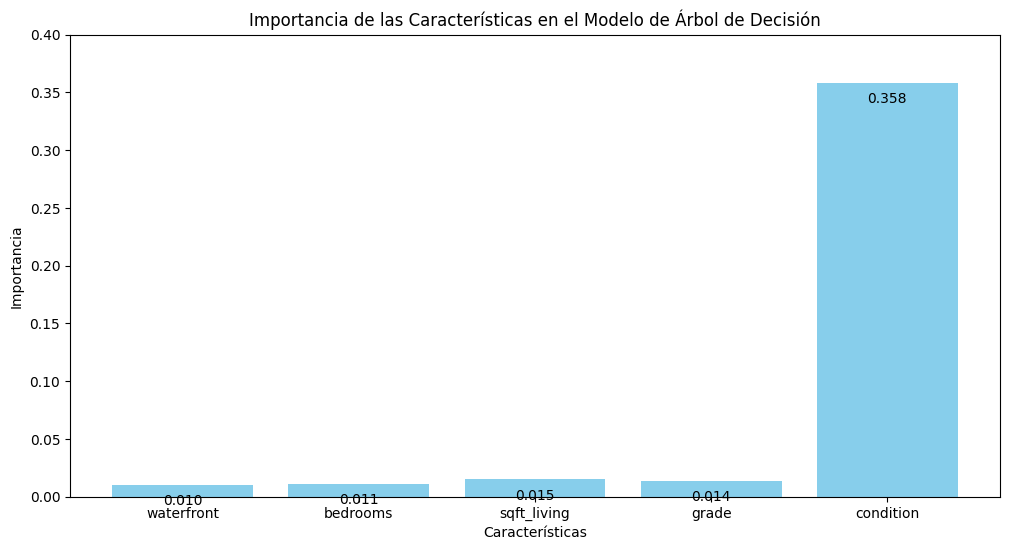

In [89]:
import matplotlib.pyplot as plt

# Importancias de las características
features = ['waterfront', 'bedrooms', 'sqft_living', 'grade', 'condition']
importances = [0.010140251696645258, 0.01123669790482846, 0.014934339316848289, 0.013671862800700173, 0.35839750044138535]

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
bars = plt.bar(features, importances, color='skyblue')

# Añadir anotaciones a las barras
for bar, importance in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.02, f'{importance:.3f}', ha='center', va='bottom', color='black', fontsize=10)

# Etiquetas y título
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.title('Importancia de las Características en el Modelo de Árbol de Decisión')
plt.ylim(0, 0.4)  # Ajustar el límite del eje y para mejor visualización
plt.show()

#Conclusiones

1.La importancia de la característica 'waterfront' en el modelo de Árbol de Decisión es de 0.0101, lo que sugiere que aunque las casas con vista al agua pueden tener precios mayores, esta variable no es tan determinante en el modelo comparado con otras características.

2.La importancia de 'bedrooms' es de 0.0112, mientras que la importancia de 'sqft_living' es de 0.0149. Esto confirma que los metros cuadrados tienen una influencia ligeramente mayor en el precio de las casas que el número de habitaciones.

3.La importancia de 'grade' es de 0.0137 y la de 'condition' es de 0.3584. Esto indica que la condición de la casa tiene un impacto significativamente mayor en el precio en comparación con la calificación, confirmando la hipótesis de que las casas en mejor condición se venden a precios más altos.

Los resultados del modelo Lasso muestran que las características más importantes para predecir el precio de las casas son sqft_living, bedrooms, bathrooms, grade, y sqft_above. Esto confirma parcialmente mis hipótesis, destacando la relevancia de los metros cuadrados y la calificación de la casa, mientras que características como la vista al agua (waterfront) y la condición (condition) no fueron seleccionadas, sugiriendo una menor influencia en este modelo en particular.